# Calibration X6Y3 — the qcal-parity chain (co-simulation)

The hardware notebook **`Calibration_X6Y3_single_QCal.ipynb`** (qcal + QubiC on the real X6Y3 chip,
session of **2026-07-26**), reproduced step-for-step with `riscq.cal` against the Verilated
`PulseTableSoc` (spec [13-qcal-parity](../specs/software/13-qcal-parity.md), re-parity in
[20](../specs/software/20-single-qcal-notebook-parity.md)). The config of record is a **qcal tree**
loaded by `Config.from_qcal` — here a co-sim-scaled two-qubit copy
([`calibration_x6y3_cosim.yaml`](calibration_x6y3_cosim.yaml)) of the real
`build/qcal-x6y3-config/config.yaml`, with `readout/herald: true` exactly like the device. The
on-hardware twin — the same chain on the real ZCU216 against the real tree — is
[`calibration_x6y3.ipynb`](calibration_x6y3.ipynb).

| reference cell | here |
|---|---|
| preamble: chassis ip/port + `configs_x6y3/` | boot the co-sim + copy the qcal tree to a working file |
| `ReadoutCalibration(gate='X90', n_levels=2)` ×3 + a manual demod-phase cell | **one** run — our phase proposal is absolute (a fixed point), so the reference's converge-loop is unnecessary |
| `Separation`: `readout/{q}/freq` ± 2.5 MHz | same span; argmax of the two-state **cluster SNR** (qcal's formula) |
| `Separation`/`Fidelity` on `demod/time`, `readout/{q}/time`, `demod/delay` | three `Window` sweeps, `durs` a `{q: [seconds]}` dict so each core sweeps around **its own** timing (spec 20 U3) |
| `Fidelity`: `readout/{q}/amp` ± 0.005, fixed classifier | same knob, scored by the confusion diagonal of the **hardware `res` bit** |
| `ReadoutFidelity`: confusion matrix | same, under the fixed discriminator |
| `Frequency(detunings, t_max=1 µs)`, all qubits | same V-fit `a·|x−b|+c`; the detunings stay co-sim-scaled (they bracket the planted ± 60-code error, not X6Y3's drift) |
| `Amplitude(X90)` coarse 0 → 1.0 + fine 0.7–1.3×, `n_gates=4` | same two passes |
| `Amplitude(X)` coarse 0 → 1.0 + fine 0.8–1.2×, `n_gates=4` | same two passes — the tree's X is a real pulse (double LENGTH, same amp), so it has its own amplitude |
| `Phase(X90)`: one absolute pass, all qubits, ± 0.3 | same — qcal's `Y180_X90`/`X180_Y90` line crossing on the virtual-Z pair |
| `Phase(X)`: ± 0.3 | same — the X's own AXIS phase, from the `X90 · X · X90` fringe minimum |

Deliberate differences (spec 13 §2): sweeps run as **on-core loops** (not circuit batches), so shots
are co-sim-scaled (16–80, not 3000–5000); discrimination is the **on-chip `res` bit** (the classifier
that actually gates feedback); a failed fit **refuses** to update the config instead of falling back
to argmax — **per qubit** (spec 20 U0), so one core's refusal does not veto the other. Every cell
reloads the working config from disk (the reference's `cfg.load()`) and an applied proposal is
written back with `save_qcal` — the full round trip through the qcal tree.

Both qubits (one per core of the `sim-2q` build) are calibrated **simultaneously**: their readouts
are frequency-multiplexed on the shared converter pair and the model tones sum on the ADC (spec 13 §8).

In [1]:
import math
import shutil
from pathlib import Path

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import riscq
from riscq.cal import (Config, ReadoutCalibration, Separation, Window, Fidelity, ReadoutFidelity,
                       Frequency, Amplitude, Phase)
from riscq.cal.base import gate_sigma, GATE_ENV
from riscq.map import SocMap, SocParams
from riscq.pulses import Pulse, units
from riscq.sim import server

MHz, us, ns = 1e6, 1e-6, 1e-9

## Bring up the co-sim and the config of record

The reference preamble points at a chassis (`ip_address`/`port`) and a config dir; here the chassis
is the Verilated SoC and the config is the co-sim-scaled qcal tree, copied to a **working file** that
every cell reloads (`cfg.load()` in the reference) and every applied proposal is saved back into.

In [2]:
SW = Path(riscq.__file__).resolve().parents[1]              # .../software
SRC = SW.parent / 'examples' / 'calibration_x6y3_cosim.yaml'      # the pristine qcal tree (co-sim scaled)
WORK = SW / 'build' / 'calibration_x6y3_config.yaml'        # the working copy (the reference's basedir)
WORK.parent.mkdir(exist_ok=True)
shutil.copy(SRC, WORK)

drv = server.start(SW / 'configs' / 'sim-2q.json', SW / 'build' / 'sim-2q')
m = SocMap(SocParams.from_json(drv.sim.get_params()))
QUBITS = [0, 1]

cfg = Config.from_qcal(WORK)
cfg.check_hardware(m.params)     # the tree's hardware section must describe THIS build (spec 13 Q0)
print('cosim up; qubits =', QUBITS, ' herald =', cfg['readout/herald'])

cosim up; qubits = [0, 1]  herald = True


## Plant the ground truth and mis-set the starting config

The reference calibrates real qubits; here each core gets a projective `TwoLevelModel` with a
**planted** Rabi rate — odd multiples of π per full-scale X90·X90 so the uncalibrated prep still
lands on |1⟩ for the readout steps. The readout tones sum on the shared ADC (`kind: multi`).
The working tree then gets a deliberate error to recover: each qubit's frequency off by ∓60 codes
(both update signs exercised, spec 13 Q4) on top of the tree's uncalibrated X90 amp (0.5).

In [3]:
F_GE = 50e6
x90_full = Pulse(GATE_ENV, freq_hz=F_GE, amp=0.5)
sig_max = gate_sigma(m, x90_full, F_GE, units.AMP_SCALE - 600)   # drive integral at full scale
g = sig_max / (units.AMP_SCALE - 600)                            # drive per amp code (linear)

RABI = {0: float(3 * math.pi / sig_max), 1: float(5 * math.pi / sig_max)}
RO_CODE = {0: 2048, 1: 1024}                     # the two multiplex slots (12.5 / 6.25 MHz)
TRUE_AMP = {q: (math.pi / 2) / (RABI[q] * g) / units.AMP_SCALE for q in QUBITS}

# readout budget: relax (3200) >> t1 (600) >> SEP, high-SNR clusters (noise 300 vs amp 14000);
# readout_amp is halved vs the single-qubit tests so the two summed tones stay in converter range.
drv.sim.set_model({'kind': 'multi', 'models': [
    dict(kind='twolevel', core=q, rabi_rad_per_amp=RABI[q], readout_code=RO_CODE[q],
         readout_amp=14000.0, readout_phase=0.0, f_ge=F_GE, t1=600, t2=3000,
         noise_scale=300.0, noise_seed=11 + q, collapse=True) for q in QUBITS]})

D_CODE = {0: +60, 1: -60}
cfg = Config.from_qcal(WORK)
for q in QUBITS:
    off = units._freq_code(F_GE, m.params) + D_CODE[q]
    cfg[f'qubit/{q}/freq'] = float(units.code_to_freq(off, m.params))
cfg.save_qcal(WORK)

for q in QUBITS:
    print(f"q{q}: start freq err {abs(cfg[f'qubit/{q}/freq'] - F_GE):.4g} Hz   "
          f"X90 amp {cfg[f'qubit/{q}/x90/amp']} (true ~{TRUE_AMP[q]:.4f})")

def step(cal):
    '''run -> print -> apply the qubits that passed -> persist (per-qubit write-back, spec 20 U0).'''
    r = cal.run(drv)
    bad = sorted(q for q, v in r.oks.items() if not v)
    print(f'{r.label}: ok={r.ok}  proposal={r.proposal}')
    if r.ok or any(r.oks.values()):
        r.apply()                                # writes only the passing qubits' paths
        cfg.save_qcal(WORK)
        if bad:
            print(f'  qubits {bad} failed — their config left unchanged (recentre/widen and re-run)')
    else:
        print('  fit failed — config left unchanged (fail-loud, spec 13 §2)')
    return r

q0: start freq err 1.465e+06 Hz   X90 amp 0.5 (true ~0.1616)
q1: start freq err 1.465e+06 Hz   X90 amp 0.5 (true ~0.0970)


# Readout Calibration

Reference: `ReadoutCalibration(..., gate='X90', n_shots=5000, n_levels=2)` — prep |0⟩ and |1⟩
(X90·X90), cluster the raw IQ, persist the classifier. Here the "classifier" is the on-chip
discriminator: the proposal fixes each qubit's `demod/phase` so the |0⟩→|1⟩ cluster axis lands on
+real, where `sign(sumR)` separates them (spec 13 Q2).

ReadoutCalibration [0, 1]: ok=True  proposal={'readout/0/demod/phase': 1.6082485462706908, 'readout/0/res_sign': 1, 'readout/1/demod/phase': 0.8254045918170936, 'readout/1/res_sign': 1}


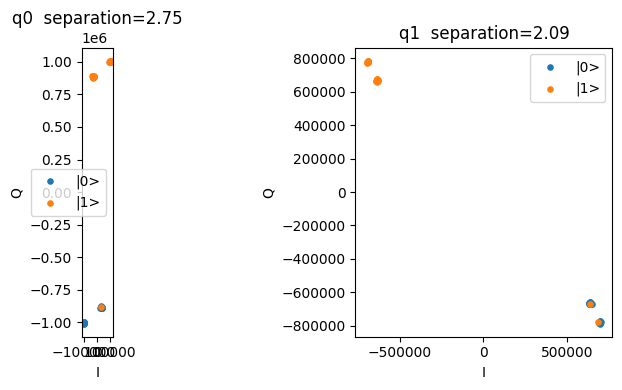

In [4]:
cfg = Config.from_qcal(WORK)
rc = step(ReadoutCalibration(cfg, QUBITS, shots=24, gate='X90'))

fig, axes = plt.subplots(1, len(QUBITS), figsize=(8, 4))
for q, ax in zip(QUBITS, axes):
    d = rc.data[q]
    ax.scatter(d['iq0'][:, 0], d['iq0'][:, 1], s=14, label='|0>')
    ax.scatter(d['iq1'][:, 0], d['iq1'][:, 1], s=14, label='|1>')
    ax.set_title(f"q{q}  separation={d['separation']:.2f}")
    ax.set_aspect('equal'); ax.set_xlabel('I'); ax.set_ylabel('Q'); ax.legend()
plt.tight_layout(); plt.show()

## Separation

Reference: sweep `readout/{q}/freq` ± 2.5 MHz (31 points, 3000 shots) around each qubit's current
value, both prep states, argmax of the GMM cluster SNR. Same statistic here (qcal's
`‖Δmeans‖ / Σ(2√cov)`), co-sim-sized to 7 points × 16 shots — a matched DAC+demod pair swept
on-core in RAW mode, one rerun per prep state.

Separation [0, 1]: ok=True  proposal={'readout/0/freq': 12500000.0, 'readout/1/freq': 6250000.0}


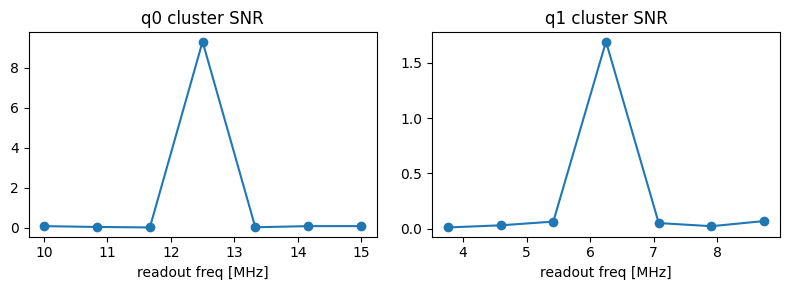

readout/0/freq -> 12.5000 MHz
readout/1/freq -> 6.2500 MHz


In [5]:
cfg = Config.from_qcal(WORK)
sep = step(Separation(cfg, QUBITS, span=2.5 * MHz, points=7, shots=16, gate='X90'))

fig, axes = plt.subplots(1, len(QUBITS), figsize=(8, 3))
for q, ax in zip(QUBITS, axes):
    ax.plot(sep.data[q]['x'] / MHz, sep.data[q]['y'], 'o-')
    ax.set_xlabel('readout freq [MHz]'); ax.set_title(f'q{q} cluster SNR')
plt.tight_layout(); plt.show()
for q in QUBITS:
    print(f"readout/{q}/freq -> {cfg[f'readout/{q}/freq'] / MHz:.4f} MHz")

## Readout timing — the three window knobs

Reference: three more `Separation` sweeps (`demod/time` ± 50 ns, `readout/{q}/time` ± 150 ns,
`demod/delay` ± 100 ns) plus a `Fidelity` sweep of `demod/delay`, each centred **per qubit**.

Here all three are `Window` — the one class that moves a readout timing — with `knob` naming the
path it writes and `durs` a `{q: [seconds]}` dict, so each core sweeps around **its own** value
while both are still read out simultaneously (spec 20 U3). One cell covers the reference's two
`demod/delay` sweeps: `Window` already scores the confusion diagonal, which is the `Fidelity`
version's statistic.

Co-sim scaling: 5 points per knob at 16 shots. This tree's `demod/delay` is **0**, so that sweep
runs 0 → +100 ns rather than ±100 ns — a negative delay is not a thing (the reference's ± span is
centred on X6Y3's 0.34–0.75 µs round trip). Every candidate keeps `delay + window` inside the
readout DRIVE, which is what the projective model emits into.

Window [0, 1] demod/dur: ok=True  proposal={'readout/0/demod/dur': 3.5000000000000004e-07, 'readout/1/demod/dur': 4.2e-07}


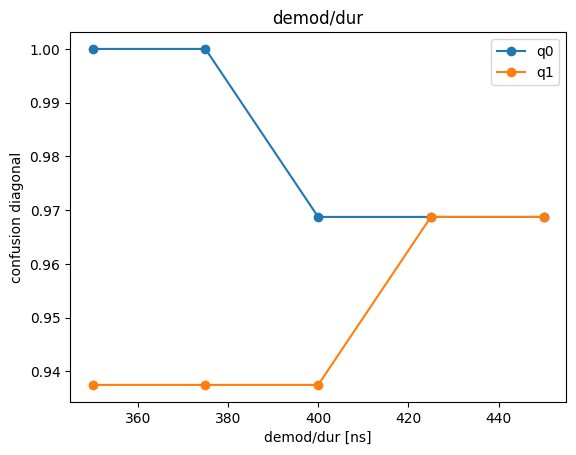

readout/0/demod/dur -> 350 ns
readout/1/demod/dur -> 420 ns


Window [0, 1] dur: ok=True  proposal={'readout/0/dur': 4.1000000000000004e-07, 'readout/1/dur': 4.8e-07}


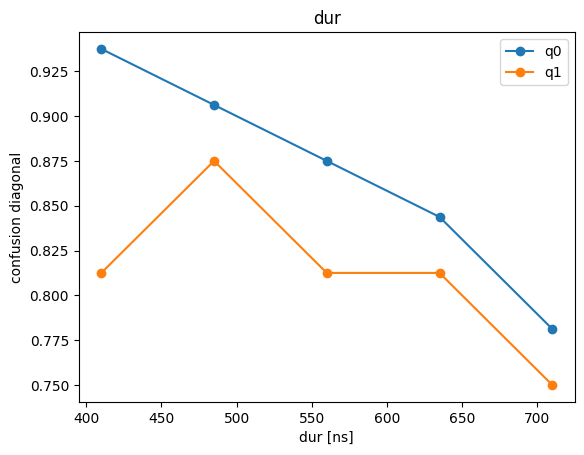

readout/0/dur -> 410 ns
readout/1/dur -> 480 ns


Window [0, 1] demod/delay: ok=True  proposal={'readout/0/demod/delay': 8e-08, 'readout/1/demod/delay': 0.0}


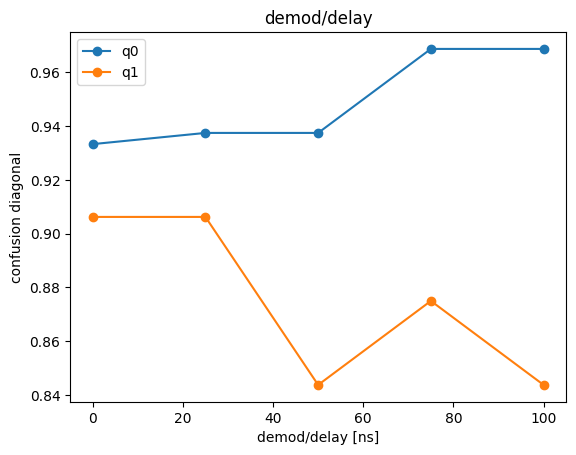

readout/0/demod/delay -> 80 ns
readout/1/demod/delay -> 0 ns


In [6]:
for knob, lo, hi in (('demod/dur', -50 * ns, 50 * ns),       # ref: Separation on demod/time
                     ('dur', -150 * ns, 150 * ns),           # ref: Separation on the DRIVE length
                     ('demod/delay', 0.0, 100 * ns)):        # ref: Separation + Fidelity (delay = 0 here)
    cfg = Config.from_qcal(WORK)                             # the reference's cfg.load() per sweep
    durs = {q: np.linspace(lo, hi, 5) + cfg[f'readout/{q}/{knob}'] for q in QUBITS}
    w = step(Window(cfg, QUBITS, durs=durs, shots=16, gate='X90', knob=knob))

    for q in QUBITS:
        plt.plot(durs[q] / ns, w.data[q]['y'], 'o-', label=f'q{q}')
    plt.xlabel(f'{knob} [ns]'); plt.ylabel('confusion diagonal')
    plt.title(knob); plt.legend(); plt.show()
    for q in QUBITS:
        print(f"readout/{q}/{knob} -> {cfg[f'readout/{q}/{knob}'] / ns:.0f} ns")

## Fidelity

Reference: disable ESP, sweep `readout/{q}/amp` ± 0.005 under the **fixed** classifier, argmax of the
confusion diagonal. Same knob and scoring here — the discriminator is the `res` bit whose phase
ReadoutCalibration just fixed, never retrained per point. (ESP is a 3-level non-goal, spec 13 §11 —
this chain is 2-level throughout.)

Fidelity [0, 1]: ok=True  proposal={'readout/0/amp': 0.5, 'readout/1/amp': 0.5}


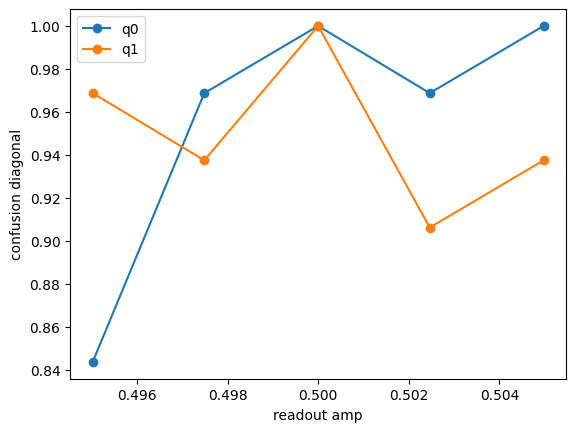

readout/0/amp -> 0.5000
readout/1/amp -> 0.5000


In [7]:
cfg = Config.from_qcal(WORK)
fid = step(Fidelity(cfg, QUBITS, amp_span=0.005, points=5, shots=16, gate='X90'))

for q in QUBITS:
    plt.plot(fid.data[q]['x'], fid.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('readout amp'); plt.ylabel('confusion diagonal'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"readout/{q}/amp -> {cfg[f'readout/{q}/amp']:.4f}")

# Readout Fidelity

Reference: `ReadoutFidelity(..., classifier=classifier)` — the confusion matrix under the classifier
passed in, no retraining. Same here: two COUNTS reruns at the calibrated amp, straight off the `res`
bit (heralded, like every counts-mode step on this `herald: true` config).

In [8]:
cfg = Config.from_qcal(WORK)
rof = step(ReadoutFidelity(cfg, QUBITS, shots=24, gate='X90'))

for q in QUBITS:
    print(f'q{q} confusion (row = prepared, col = classified):')
    print(np.round(rof.data[q]['confusion'], 3), f"  fidelity={rof.data[q]['fidelity']:.3f}")

ReadoutFidelity [0, 1]: ok=True  proposal={'readout/0/fidelity': 0.8958333333333333, 'readout/1/fidelity': 0.9166666666666667}
q0 confusion (row = prepared, col = classified):
[[1.    0.   ]
 [0.208 0.792]]   fidelity=0.896
q1 confusion (row = prepared, col = classified):
[[1.    0.   ]
 [0.167 0.833]]   fidelity=0.917


# Single Qubit
## GE
### Freq

Reference: Ramsey vs detuning — `detunings = [-5, -2.5, 2.5, 5] MHz`, `t_max = 1 µs`, fit
`a·|x − b| + c` over the unsigned fringe frequencies. Same detuning set here; `t_max` is halved
(same fringe sampling density at co-sim point counts). Both planted signs (±60 codes) must correct
toward zero (spec 13 Q4).

/config/build/agentic-rv-dev/software/riscq/cal/fits.py:67: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, x, y, p0=list(p0), maxfev=20000)


/config/build/agentic-rv-dev/software/riscq/cal/fits.py:110: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-t / tau) * np.cos(2 * np.pi * f * t + phi) + C


Frequency [0, 1]: ok=True  proposal={'qubit/0/freq': 49995652.135430805, 'qubit/1/freq': 49974986.50237972}


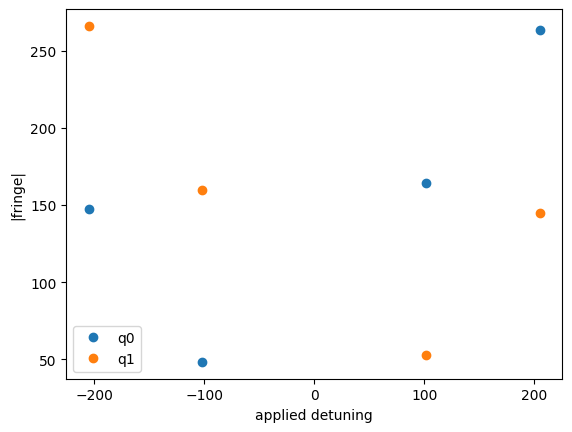

q0: freq err -> 4348 Hz  (started 1.465e+06)
q1: freq err -> 2.501e+04 Hz  (started 1.465e+06)


In [9]:
cfg = Config.from_qcal(WORK)
detunings = np.array([-5, -2.5, 2.5, 5]) * MHz          # the reference's exact set
fr = step(Frequency(cfg, QUBITS, detunings=detunings, t_max=0.5 * us, points=15, shots=64))

for q in QUBITS:
    d = fr.data[q]
    plt.plot(d['applied'], d['obs'], 'o', label=f'q{q}')
plt.xlabel('applied detuning'); plt.ylabel('|fringe|'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"q{q}: freq err -> {abs(cfg[f'qubit/{q}/freq'] - F_GE):.4g} Hz  (started {abs(units.code_to_freq(units._freq_code(F_GE, m.params) + D_CODE[q], m.params) - F_GE):.4g})")

### Amplitude X90

Reference: a coarse `n_gates=1` Rabi over the **full** amplitude range (0 → 1.0), then a fine pass —
4 repeated X90s with `relative_amp=True` sweeping 0.7–1.3× the coarse result (each X90 is a quarter
period, so the train must be a multiple of 4 — qcal's own guard).

Amplitude [0, 1] X90 n_gates=1: ok=True  proposal={'qubit/0/x90/amp': 0.16174658786206592, 'qubit/0/rabi': 7.411358992449224e-05, 'qubit/1/x90/amp': 0.09859992168590005, 'qubit/1/rabi': 0.00012160861125918076}


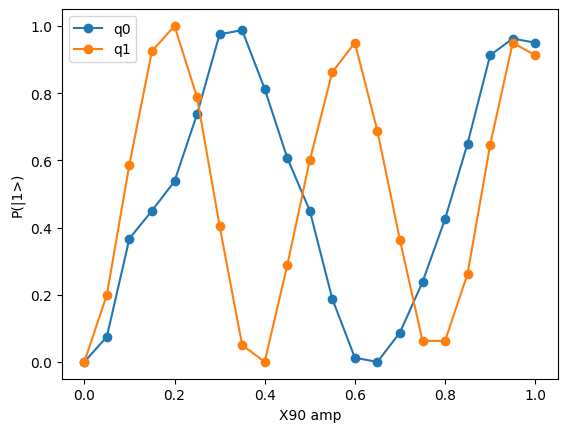

q0: coarse X90 amp -> 0.1617 (true ~0.1616)
q1: coarse X90 amp -> 0.0986 (true ~0.0970)


In [10]:
cfg = Config.from_qcal(WORK)
ac = step(Amplitude(cfg, QUBITS, gate='X90', n_gates=1, amp_span=(0.0, 1.0), points=21, shots=80))

for q in QUBITS:
    plt.plot(ac.data[q]['x'] / units.AMP_SCALE, ac.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('X90 amp'); plt.ylabel('P(|1>)'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"q{q}: coarse X90 amp -> {cfg[f'qubit/{q}/x90/amp']:.4f} (true ~{TRUE_AMP[q]:.4f})")

In [11]:
cfg = Config.from_qcal(WORK)
af = step(Amplitude(cfg, QUBITS, gate='X90', n_gates=4, amp_span=(0.7, 1.3), relative_amp=True,
                    points=13, shots=80))
for q in QUBITS:
    print(f"q{q}: fine X90 amp -> {cfg[f'qubit/{q}/x90/amp']:.4f} (true ~{TRUE_AMP[q]:.4f})")

Amplitude [0, 1] X90 n_gates=4: ok=True  proposal={'qubit/0/x90/amp': 0.1631192311971899, 'qubit/1/x90/amp': 0.09794712030115665}
q0: fine X90 amp -> 0.1631 (true ~0.1616)
q1: fine X90 amp -> 0.0979 (true ~0.0970)


### Amplitude X180

Reference: the same two passes on the **X** — coarse 0 → 1.0 at `n_gates=1`, then 0.8–1.2× at
`n_gates=4` with `relative_amp=True`.

The tree's X is a real pulse, not a double-amplitude X90: an 80 ns square against the X90's 40 ns
(mirroring X6Y3's double-length FAST_DRAG), so it carries the same drive integral at the same
amplitude — its π amplitude should land on the SAME code as the X90's π/2, which is what makes this
a check of the `gate='X'` path rather than a second measurement of the same number. The repetition
guard relaxes to a multiple of **2** here (2·X = 2π).

Amplitude [0, 1] X n_gates=1: ok=True  proposal={'qubit/0/x/amp': 0.1605353645705428, 'qubit/0/rabi': 7.467276955805823e-05, 'qubit/1/x/amp': 0.09679072909333458, 'qubit/1/rabi': 0.00012388155608352878}


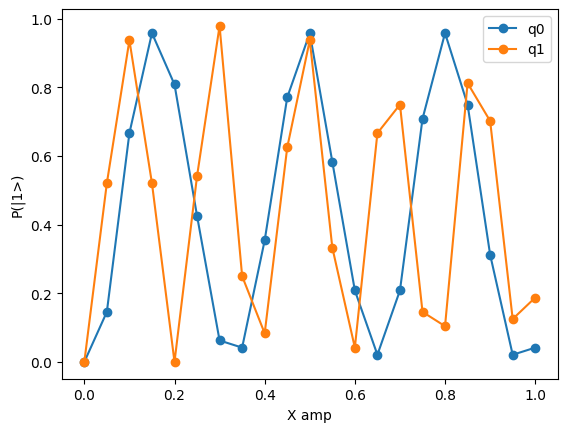

q0: coarse X amp -> 0.1605 (true ~0.1616)
q1: coarse X amp -> 0.0968 (true ~0.0970)


In [12]:
cfg = Config.from_qcal(WORK)
xc = step(Amplitude(cfg, QUBITS, gate='X', n_gates=1, amp_span=(0.0, 1.0), points=21, shots=48))

for q in QUBITS:
    plt.plot(xc.data[q]['x'] / units.AMP_SCALE, xc.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('X amp'); plt.ylabel('P(|1>)'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"q{q}: coarse X amp -> {cfg[f'qubit/{q}/x/amp']:.4f} (true ~{TRUE_AMP[q]:.4f})")

In [13]:
cfg = Config.from_qcal(WORK)
xf = step(Amplitude(cfg, QUBITS, gate='X', n_gates=4, amp_span=(0.8, 1.2), relative_amp=True,
                    points=13, shots=48))
for q in QUBITS:
    print(f"q{q}: fine X amp -> {cfg[f'qubit/{q}/x/amp']:.4f} (true ~{TRUE_AMP[q]:.4f})")

Amplitude [0, 1] X n_gates=4: ok=True  proposal={'qubit/0/x/amp': 0.16021607524500553, 'qubit/1/x/amp': 0.09667719417985156}
q0: fine X amp -> 0.1602 (true ~0.1616)
q1: fine X amp -> 0.0967 (true ~0.0970)


### Phase X90

Reference: **one absolute pass** over all qubits, `phases = np.linspace(-0.3, 0.3, 31)` (qcal's
`relative_phase` defaults False and this session never sets it). The swept knob is the X90's
**virtual-Z pair** (`qubit/{q}/x90/vz`); each point runs qcal's two sequences (`Y180_X90` /
`X180_Y90`) and the calibrated value is the crossing of the two fitted lines (spec 13 Q3), written
to both slots. The model plants no AC-Stark term, so the recovered correction should be ≈ 0.

In [14]:
cfg = Config.from_qcal(WORK)
ph = step(Phase(cfg, QUBITS, span=0.3, points=7, shots=24))    # one absolute pass, all cores

for q in QUBITS:
    vz = cfg[f'qubit/{q}/x90/vz']
    print(f'q{q}: X90 virtual-Z pair -> [{vz[0]:+.4f}, {vz[1]:+.4f}] rad  (planted 0)')

Phase [0, 1]: ok=True  proposal={'qubit/0/x90/vz': [0.2666569936274513, 0.2666569936274513], 'qubit/1/x90/vz': [0.045139428388346794, 0.045139428388346794]}
q0: X90 virtual-Z pair -> [+0.2667, +0.2667] rad  (planted 0)
q1: X90 virtual-Z pair -> [+0.0451, +0.0451] rad  (planted 0)


### Phase X180

Reference: `Phase(gate='X', phases=np.linspace(-0.3, 0.3, 101))`.

A different knob from the X90's: the X carries no virtual-Z pair, so what is calibrated is the
pulse's **own axis phase**. One `X90 · X · X90` composite — a 2π rotation that returns to |0⟩ only
when the X sits on the X90s' axis — so P(|1⟩) is cosinusoidal in the swept axis and the calibrated
value is its **minimum**. The model plants no axis offset, so the recovered phase should be ≈ 0.

(On the real chip the reference cell writes `X/pulse/1/kwargs/phase`, but X6Y3's X drive sits at
pulse index 0 — ours writes `qubit/{q}/x/phase`, which `save_qcal` maps onto whichever entry is the
drive; spec 20 §1.)

Phase [0, 1] X: ok=True  proposal={'qubit/0/x/phase': 0.018755530739177573, 'qubit/1/x/phase': 0.14999533082014485}


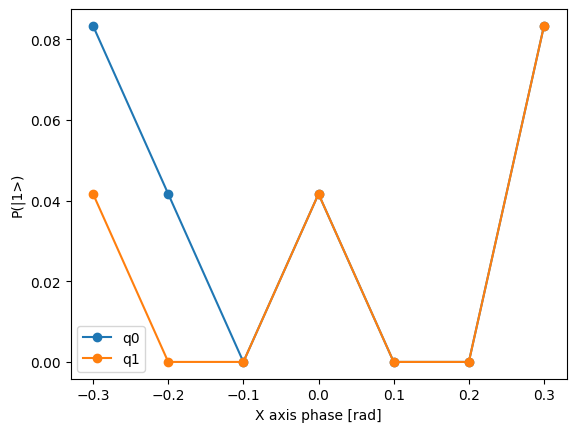

q0: X axis phase -> +0.0188 rad  (planted 0)
q1: X axis phase -> +0.1500 rad  (planted 0)


In [15]:
cfg = Config.from_qcal(WORK)
px = step(Phase(cfg, QUBITS, gate='X', span=0.3, points=7, shots=24))

for q in QUBITS:
    plt.plot(px.data[q]['x'], px.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('X axis phase [rad]'); plt.ylabel('P(|1>)'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"q{q}: X axis phase -> {cfg.get(f'qubit/{q}/x/phase', 0.0):+.4f} rad  (planted 0)")

## Summary — the qcal tree converged toward the planted truth

Every step above ran through the full parity path: `Config.from_qcal` → calibrate → `save_qcal`
back into the tree of record, on both qubits simultaneously, heralded.

In [16]:
cfg = Config.from_qcal(WORK)
improved = True
for q in QUBITS:
    f0 = abs(units.code_to_freq(units._freq_code(F_GE, m.params) + D_CODE[q], m.params) - F_GE)
    f1 = abs(cfg[f'qubit/{q}/freq'] - F_GE)
    a0 = abs(0.5 - TRUE_AMP[q])
    a1 = abs(cfg[f'qubit/{q}/x90/amp'] - TRUE_AMP[q])
    # the X is double LENGTH at the same amplitude, so its pi amp is the X90's pi/2 amp
    x0 = abs(0.495 - TRUE_AMP[q])
    x1 = abs(cfg[f'qubit/{q}/x/amp'] - TRUE_AMP[q])
    print(f'q{q}: freq err {f0:10.4g} -> {f1:10.4g} Hz   X90 amp err {a0:.4f} -> {a1:.4f}   '
          f'X amp err {x0:.4f} -> {x1:.4f}   '
          f"readout fidelity {rof.data[q]['fidelity']:.3f}")
    improved &= f1 < f0 and a1 < a0 and x1 < x0
assert improved, 'calibration did not improve the config on both qubits'
print('\nOK — both qubits pulled toward the planted truth through the qcal round-trip.')

q0: freq err  1.465e+06 ->       4348 Hz   X90 amp err 0.3384 -> 0.0015   X amp err 0.3334 -> 0.0014   readout fidelity 0.896
q1: freq err  1.465e+06 ->  2.501e+04 Hz   X90 amp err 0.4030 -> 0.0010   X amp err 0.3980 -> 0.0003   readout fidelity 0.917

OK — both qubits pulled toward the planted truth through the qcal round-trip.


## Tear down the co-sim

In [17]:
drv.sim.set_model({'kind': 'zero'})
server.stop(drv)
print('cosim stopped')

cosim stopped
